# Mismodeling Grid

Inject and recover `SPL`, `BPL`, and `Cutoff`

In [42]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from load_config import load_config
from samplers import (
    run_rwmh,
    run_mala,
    run_multiple_chains,
    build_spectral_logpost_and_grad,
    make_theta_init_for_model,
    posterior_summary_multi,
    _stack_chains,
    split_rhat,
    effective_sample_size_multi,
)

from simulator import E_REF, generate_single_season, signal_counts_for_model

MODEL_ORDER = ["power_law", "broken_power_law", "cutoff"]
MODEL_LABEL = {"power_law": "SPL", "broken_power_law": "BPL", "cutoff": "Cutoff"}


def get_injection_params(truth_model, config=None, use_mese_like=True):
    if config is None:
        config = load_config()

    signal_cfg = config["signal"]
    mese_cfg = config.get("signal_mese_like", {})

    if (not use_mese_like) or (not mese_cfg):
        return {
            "phi": float(signal_cfg["phi"]),
            "gamma": float(signal_cfg["gamma"]),
            "gamma2": float(signal_cfg["gamma2"]),
            "E_break": float(signal_cfg["E_break"]),
            "E_cut": float(signal_cfg["E_cut"]),
        }

    if truth_model == "power_law":
        spl = mese_cfg["spl"]
        return {
            "phi": float(spl["phi0_100tev"]),
            "gamma": float(spl["gamma"]),
            "gamma2": float(signal_cfg["gamma2"]),
            "E_break": float(signal_cfg["E_break"]),
            "E_cut": float(signal_cfg["E_cut"]),
        }

    if truth_model == "broken_power_law":
        bpl = mese_cfg["bpl"]
        phi0 = float(bpl["phi0_100tev"])
        g1 = float(bpl["gamma1"])
        g2 = float(bpl["gamma2"])
        e_break = float(bpl["E_break"])
        phi_sim = phi0 * (E_REF / e_break) ** (g2 - g1)
        return {
            "phi": float(phi_sim),
            "gamma": float(g1),
            "gamma2": float(g2),
            "E_break": float(e_break),
            "E_cut": float(signal_cfg["E_cut"]),
        }

    if truth_model == "cutoff":
        co = mese_cfg["cutoff"]
        return {
            "phi": float(co["phi0_100tev"]),
            "gamma": float(co["gamma"]),
            "gamma2": float(signal_cfg["gamma2"]),
            "E_break": float(signal_cfg["E_break"]),
            "E_cut": float(co["E_cut"]),
        }

    raise ValueError(f"Unknown truth_model: {truth_model}")


def generate_mismodeling_dataset(truth_model, config=None, use_mese_like=True, rng=None):
    if config is None:
        config = load_config()
    if rng is None:
        seed = int(config["testing"]["seed_samplers"])
        rng = np.random.default_rng(seed)

    bins_cfg = config["energy_bins"]
    background_cfg = config["background"]
    atmo_cfg = config["atmospheric_realism"]
    det_cfg = config["detector_response"]
    prior_cfg = config["priors"]["physics"]
    inj = get_injection_params(truth_model, config=config, use_mese_like=use_mese_like)

    eta_prompt = float(
        background_cfg.get(
            "eta_prompt",
            float(background_cfg["eta"]) * float(atmo_cfg.get("prompt_fraction", 0.0)),
        )
    )

    return generate_single_season(
        phi=inj["phi"],
        gamma=inj["gamma"],
        eta=float(background_cfg["eta"]),
        delta=float(background_cfg["delta"]),
        truth_model=truth_model,
        n_bins=int(bins_cfg["n_bins"]),
        E_min=float(bins_cfg["E_min"]),
        E_max=float(bins_cfg["E_max"]),
        gamma2=inj["gamma2"],
        E_break=inj["E_break"],
        E_cut=inj["E_cut"],
        atmo_model=atmo_cfg["model"],
        prompt_fraction=float(atmo_cfg["prompt_fraction"]),
        eta_prompt=eta_prompt,
        delta_prompt=float(atmo_cfg["delta_prompt"]),
        E_knee=float(atmo_cfg["E_knee"]),
        knee_sharpness=float(atmo_cfg["knee_sharpness"]),
        prompt_prior_log_mean=float(atmo_cfg.get("prompt_prior_log_mean", np.log(1e-6))),
        prompt_prior_log_sd=float(atmo_cfg.get("prompt_prior_log_sd", 1.0)),
        prior_phi_log_mean=float(prior_cfg["phi_log_mean"]),
        prior_phi_log_sd=float(prior_cfg["phi_log_sd"]),
        prior_gamma_mean=float(prior_cfg["gamma_mean"]),
        prior_gamma_sd=float(prior_cfg["gamma_sd"]),
        prior_eta_log_mean=float(prior_cfg["eta_log_mean"]),
        prior_eta_log_sd=float(prior_cfg["eta_log_sd"]),
        prior_delta_mean=float(prior_cfg["delta_mean"]),
        prior_delta_sd=float(prior_cfg["delta_sd"]),
        detector_mode=det_cfg["mode"],
        livetime_years=float(det_cfg["livetime_years"]),
        sigma_log10=float(det_cfg["sigma_log10"]),
        physical_flux_units=bool(det_cfg.get("physical_flux_units", False)),
        hese75_aeff_allsky_path=det_cfg.get("hese75_aeff_allsky_path", None),
        hese75_migration_path=det_cfg.get("hese75_migration_path", None),
        hese75_sky_factor_sr=float(det_cfg.get("hese75_sky_factor_sr", 4.0 * np.pi)),
        rng=rng,
    )


def run_single_mismodeling_case(ds, recover_model, config=None, prior_type=None, rng=None):
    if config is None:
        config = load_config()
    if rng is None:
        seed = int(config["testing"]["seed_samplers"])
        rng = np.random.default_rng(seed)

    if prior_type is None:
        prior_type = str(config["priors"]["default"])

    rwmh_cfg = config["samplers"]["RWMH"]
    mala_cfg = config["samplers"]["MALA"]
    test_cfg = config["testing"]
    signal_cfg = config["signal"]

    logpost, grad_logpost, param_names = build_spectral_logpost_and_grad(
        ds,
        recover_model=recover_model,
        prior_type=prior_type,
        eps=1e-5,
    )
    theta_init = make_theta_init_for_model(ds, recover_model, param_names, signal_cfg)

    rwmh = run_multiple_chains(
        run_rwmh,
        theta_init=theta_init,
        n_chains=int(test_cfg["n_chains"]),
        init_strategy=test_cfg["init_strategy"],
        init_scale=float(test_cfg["init_scale_base"]),
        rng=rng,
        log_posterior_fn=logpost,
        n_iterations=int(rwmh_cfg["n_iterations"]),
        n_burnin=int(rwmh_cfg["n_burnin"]),
        adapt_proposal=bool(rwmh_cfg["adapt_proposal"]),
        adapt_until=int(rwmh_cfg["adapt_until"]),
        adapt_interval=int(rwmh_cfg["adapt_interval"]),
        target_accept=float(rwmh_cfg["target_accept"]),
        param_names=param_names,
        verbose=False,
    )
    mala = run_multiple_chains(
        run_mala,
        theta_init=theta_init,
        n_chains=int(test_cfg["n_chains"]),
        init_strategy=test_cfg["init_strategy"],
        init_scale=float(test_cfg["init_scale_base"]),
        rng=rng,
        log_posterior_fn=logpost,
        grad_log_posterior_fn=grad_logpost,
        n_iterations=int(mala_cfg["n_iterations"]),
        n_burnin=int(mala_cfg["n_burnin"]),
        step_size=float(mala_cfg["step_size"]),
        adapt_step=bool(mala_cfg["adapt_step"]),
        adapt_until=int(mala_cfg["adapt_until"]),
        adapt_interval=int(mala_cfg["adapt_interval"]),
        target_accept=float(mala_cfg["target_accept"]),
        param_names=param_names,
        precond_type=mala_cfg["precond_type"],
        normalize_precond=bool(mala_cfg["normalize_precond"]),
        adapt_precond=bool(mala_cfg["adapt_precond"]),
        verbose=False,
    )

    return {
        "param_names": param_names,
        "theta_init": theta_init,
        "rwmh": rwmh,
        "mala": mala,
        "rwmh_summary": posterior_summary_multi(rwmh, ci=0.90, true_values=ds.true_params),
        "mala_summary": posterior_summary_multi(mala, ci=0.90, true_values=ds.true_params),
    }



In [43]:
# Runtime controls
USE_MESE_INJECTION = True
PRIOR_TYPE = None   # None -> config default
SEED = 221
FAST_MODE = False

config = load_config()
config = copy.deepcopy(config)

if FAST_MODE:
    config['samplers']['RWMH']['n_iterations'] = 4000
    config['samplers']['RWMH']['n_burnin'] = 1000
    config['samplers']['MALA']['n_iterations'] = 6000
    config['samplers']['MALA']['n_burnin'] = 2000

rng_master = np.random.default_rng(SEED)
inject_models = MODEL_ORDER
recover_models = MODEL_ORDER

print('Inject models:', inject_models)
print('Recover models:', recover_models)
print('Prior:', PRIOR_TYPE or config['priors']['default'])

Inject models: ['power_law', 'broken_power_law', 'cutoff']
Recover models: ['power_law', 'broken_power_law', 'cutoff']
Prior: weakly


In [44]:
case_store = {}
rows = []

for inject_model in inject_models:
    ds = generate_mismodeling_dataset(
        inject_model,
        config=config,
        use_mese_like=USE_MESE_INJECTION,
        rng=np.random.default_rng(rng_master.integers(0, 2**32 - 1)),
    )

    for recover_model in recover_models:
        out = run_single_mismodeling_case(
            ds,
            recover_model,
            config=config,
            prior_type=PRIOR_TYPE,
            rng=np.random.default_rng(rng_master.integers(0, 2**32 - 1)),
        )

        rwmh_stack = _stack_chains(out['rwmh'])
        mala_stack = _stack_chains(out['mala'])

        rwmh_rhats = [split_rhat(rwmh_stack[:, :, j]) for j in range(rwmh_stack.shape[2])]
        mala_rhats = [split_rhat(mala_stack[:, :, j]) for j in range(mala_stack.shape[2])]
        rwmh_ess = [effective_sample_size_multi(rwmh_stack[:, :, j]) for j in range(rwmh_stack.shape[2])]
        mala_ess = [effective_sample_size_multi(mala_stack[:, :, j]) for j in range(mala_stack.shape[2])]

        row = {
            'inject_model': inject_model,
            'recover_model': recover_model,
            'rwmh_rhat_max': float(np.nanmax(rwmh_rhats)),
            'mala_rhat_max': float(np.nanmax(mala_rhats)),
            'rwmh_ess_min': float(np.nanmin(rwmh_ess)),
            'mala_ess_min': float(np.nanmin(mala_ess)),
            'rwmh_accept_mean': float(np.mean([r.acceptance_rate for r in out['rwmh']])),
            'mala_accept_mean': float(np.mean([r.acceptance_rate for r in out['mala']])),
        }

        for summary_name, summary in [('rwmh', out['rwmh_summary']), ('mala', out['mala_summary'])]:
            for _, v in summary.items():
                dname = v['display_name']
                row[f'{summary_name}_{dname}_mean'] = v['mean']
                row[f'{summary_name}_{dname}_sd'] = v['sd']

        rows.append(row)

        case_store[(inject_model, recover_model)] = {
            'ds': ds,
            'names': out['param_names'],
            'rwmh': out['rwmh'],
            'mala': out['mala'],
            'rwmh_summary': out['rwmh_summary'],
            'mala_summary': out['mala_summary'],
            'row': row,
        }

res_df = pd.DataFrame(rows)
res_df.sort_values(['inject_model', 'recover_model'])

,inject_model,recover_model,rwmh_rhat_max,mala_rhat_max,rwmh_ess_min,mala_ess_min,rwmh_accept_mean,mala_accept_mean,rwmh_phi_mean,rwmh_phi_sd,...,mala_gamma1_mean,mala_gamma1_sd,mala_gamma2_mean,mala_gamma2_sd,mala_E_break_mean,mala_E_break_sd,rwmh_E_cut_mean,rwmh_E_cut_sd,mala_E_cut_mean,mala_E_cut_sd
4,broken_power_law,broken_power_law,1.011385,1.117450,460.214576,72.959660,0.221188,0.645000,2.361720e-18,1.633663e-18,...,2.554176,0.410492,2.761185,0.241026,49715.476244,44706.413300,NaN,NaN,NaN,NaN
5,broken_power_law,cutoff,1.006378,1.124938,582.282437,87.035944,0.226913,0.675725,2.029808e-18,1.163399e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,1.718795e+06,1.920239e+06,1.505833e+06,1.459074e+06
3,broken_power_law,power_law,1.025960,1.067591,559.072126,75.981499,0.217537,0.614525,2.373169e-18,1.428644e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,cutoff,broken_power_law,1.007050,1.080018,470.930444,72.344787,0.242300,0.621975,2.329372e-18,1.985063e-18,...,2.543442,0.380895,2.787818,0.239695,42775.788220,58960.145871,NaN,NaN,NaN,NaN
8,cutoff,cutoff,1.021988,1.094652,359.137661,69.686296,0.239000,0.613233,2.260775e-18,1.508147e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,1.435060e+06,1.625456e+06,1.520323e+06,1.598292e+06
6,cutoff,power_law,1.004660,1.079129,782.368169,87.564737,0.238700,0.628142,2.183536e-18,1.370906e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,power_law,broken_power_law,1.018243,1.122052,246.303087,81.309254,0.238613,0.634875,2.683666e-18,2.193085e-18,...,2.562433,0.406988,2.776323,0.243487,46628.652030,45457.066199,NaN,NaN,NaN,NaN
2,power_law,cutoff,1.008611,1.056191,269.407565,90.774190,0.230900,0.640225,2.185747e-18,1.257224e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,1.589358e+06,1.671152e+06,1.330991e+06,1.355004e+06
0,power_law,power_law,1.005397,1.075760,552.840327,86.314316,0.224712,0.638592,2.447139e-18,1.448407e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
print('Max R-hat by case (RWMH / MALA):')
display(
    res_df[['inject_model','recover_model','rwmh_rhat_max','mala_rhat_max']]
    .sort_values(['inject_model','recover_model'])
)

print('Min ESS by case (RWMH / MALA):')
display(
    res_df[['inject_model','recover_model','rwmh_ess_min','mala_ess_min']]
    .sort_values(['inject_model','recover_model'])
)


Max R-hat by case (RWMH / MALA):


,inject_model,recover_model,rwmh_rhat_max,mala_rhat_max
4,broken_power_law,broken_power_law,1.011385,1.117450
5,broken_power_law,cutoff,1.006378,1.124938
3,broken_power_law,power_law,1.025960,1.067591
7,cutoff,broken_power_law,1.007050,1.080018
8,cutoff,cutoff,1.021988,1.094652
6,cutoff,power_law,1.004660,1.079129
1,power_law,broken_power_law,1.018243,1.122052
2,power_law,cutoff,1.008611,1.056191
0,power_law,power_law,1.005397,1.075760


Min ESS by case (RWMH / MALA):


,inject_model,recover_model,rwmh_ess_min,mala_ess_min
4,broken_power_law,broken_power_law,460.214576,72.959660
5,broken_power_law,cutoff,582.282437,87.035944
3,broken_power_law,power_law,559.072126,75.981499
7,cutoff,broken_power_law,470.930444,72.344787
8,cutoff,cutoff,359.137661,69.686296
6,cutoff,power_law,782.368169,87.564737
1,power_law,broken_power_law,246.303087,81.309254
2,power_law,cutoff,269.407565,90.774190
0,power_law,power_law,552.840327,86.314316


In [46]:
def summary_to_natural_params(summary_dict, recover_model):
    p = {}
    for _, s in summary_dict.items():
        p[s['display_name']] = s['mean']

    # Ensure required keys exist for each recover model
    if recover_model == 'power_law':
        return {'phi': p['phi'], 'gamma': p['gamma']}
    if recover_model == 'broken_power_law':
        return {
            'phi': p['phi'],
            'gamma1': p['gamma1'],
            'gamma2': p['gamma2'],
            'E_break': p['E_break'],
        }
    if recover_model == 'cutoff':
        return {
            'phi': p['phi'],
            'gamma': p['gamma'],
            'E_cut': p['E_cut'],
        }
    raise ValueError(f'Unknown recover model: {recover_model}')


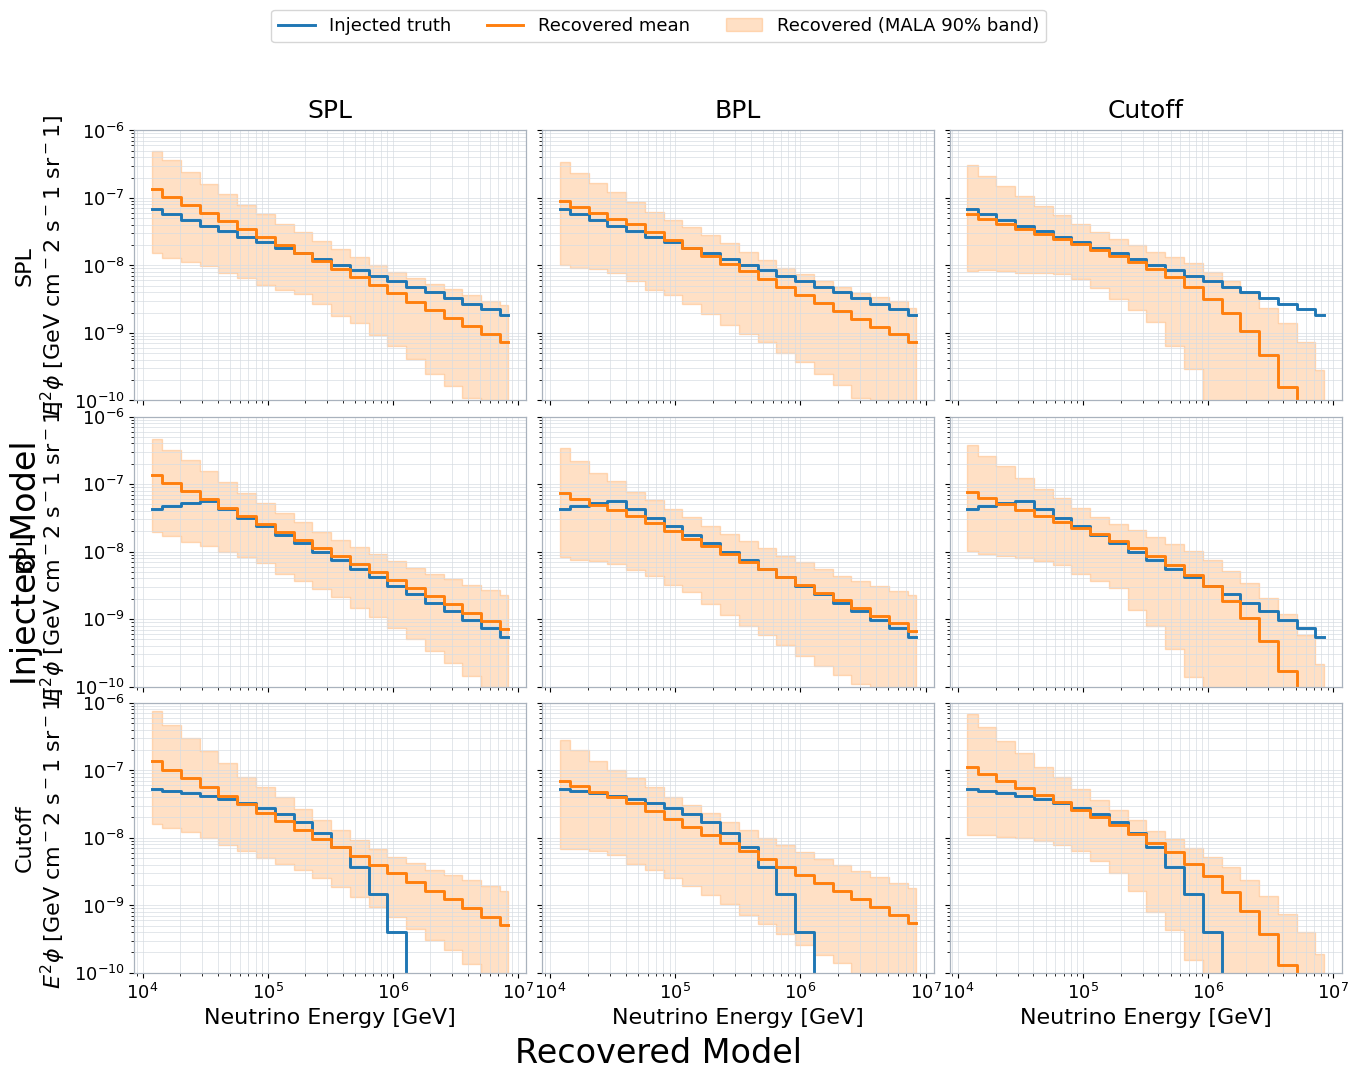

In [47]:
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
})

fig, axes = plt.subplots(
    len(inject_models), len(recover_models),
    figsize=(4.6 * len(recover_models), 3.6 * len(inject_models)),
    sharex=True,
    sharey=True,
)
axes = np.array(axes)

for i, inj in enumerate(inject_models):
    for j, rec in enumerate(recover_models):
        ax = axes[i, j]
        cs = case_store[(inj, rec)]
        ds = cs['ds']

        # Choose sampler for overlay: prefer MALA if converged enough
        use_mala = np.isfinite(cs['row']['mala_rhat_max']) and (cs['row']['mala_rhat_max'] < 1.2)
        summary = cs['mala_summary'] if use_mala else cs['rwmh_summary']
        samples = cs['mala'] if use_mala else cs['rwmh']
        band_label = 'Recovered (MALA 90% band)' if use_mala else 'Recovered (RWMH 90% band)'

        # Injected truth (signal only)
        tp = ds.true_params
        if inj == 'power_law':
            p_true = {'phi': tp['phi'], 'gamma': tp['gamma']}
        elif inj == 'broken_power_law':
            p_true = {'phi': tp['phi'], 'gamma1': tp['gamma'], 'gamma2': tp['gamma2'], 'E_break': tp['E_break']}
        elif inj == 'cutoff':
            p_true = {'phi': tp['phi'], 'gamma': tp['gamma'], 'E_cut': tp['E_cut']}
        else:
            raise ValueError(inj)

        mu_true = signal_counts_for_model(ds.E_centers, ds.E_widths, inj, p_true)
        phi_true = np.clip(mu_true / ds.E_widths, 1e-40, None)
        e2phi_true = ds.E_centers**2 * phi_true

        # Recovered posterior mean (signal only)
        p_rec = summary_to_natural_params(summary, rec)
        mu_rec = signal_counts_for_model(ds.E_centers, ds.E_widths, rec, p_rec)
        phi_rec = np.clip(mu_rec / ds.E_widths, 1e-40, None)
        e2phi_rec = ds.E_centers**2 * phi_rec

        # 90% recovered band from posterior draws
        chain_arr = _stack_chains(samples).reshape(-1, _stack_chains(samples).shape[-1])
        n_draw = min(250, len(chain_arr))
        idx = np.linspace(0, len(chain_arr)-1, n_draw, dtype=int)
        draws = []

        for k in idx:
            vec = chain_arr[k]
            name_map = {name: vec[ii] for ii, name in enumerate(cs['names'])}
            # convert transformed -> natural
            p_draw = {n: (np.exp(v) if n.startswith('log_') else v) for n, v in name_map.items()}
            p_nat = {k2.replace('log_', ''): float(v2) for k2, v2 in p_draw.items()}

            if rec == 'power_law':
                pars = {'phi': p_nat['phi'], 'gamma': p_nat['gamma']}
            elif rec == 'broken_power_law':
                pars = {'phi': p_nat['phi'], 'gamma1': p_nat['gamma1'], 'gamma2': p_nat['gamma2'], 'E_break': p_nat['E_break']}
            else:
                pars = {'phi': p_nat['phi'], 'gamma': p_nat['gamma'], 'E_cut': p_nat['E_cut']}

            mu_d = signal_counts_for_model(ds.E_centers, ds.E_widths, rec, pars)
            phi_d = np.clip(mu_d / ds.E_widths, 1e-40, None)
            draws.append(ds.E_centers**2 * phi_d)

        draws = np.asarray(draws)
        lo = np.quantile(draws, 0.05, axis=0)
        hi = np.quantile(draws, 0.95, axis=0)

        # plot
        ax.step(ds.E_centers, e2phi_true, where='mid', lw=2.1, color='tab:blue', label='Injected truth')
        ax.step(ds.E_centers, e2phi_rec, where='mid', lw=2.1, color='tab:orange', label='Recovered mean')
        ax.fill_between(
            ds.E_centers,
            np.clip(lo, 1e-40, None),
            np.clip(hi, 1e-40, None),
            step='mid',
            color='tab:orange',
            alpha=0.24,
            label=band_label if (i == 0 and j == 0) else None,
        )

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_ylim(1e-10, 1e-6)
        ax.grid(True, which='both', color='#D7DCE2', alpha=0.7, linewidth=0.7)

        for spine in ax.spines.values():
            spine.set_color('#A9B2BD')
            spine.set_linewidth(0.9)

        if i == 0:
            ax.set_title(MODEL_LABEL[rec], pad=9)
        if j == 0:
            ax.set_ylabel(f"{MODEL_LABEL[inj]}\n$E^2\phi$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")
        if i == len(inject_models)-1:
            ax.set_xlabel('Neutrino Energy [GeV]')

fig.supylabel('Injected Model', x=0.03, fontsize=24)
fig.supxlabel('Recovered Model', y=0.03, fontsize=24)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=True, bbox_to_anchor=(0.5, 1.02), fontsize=13)

fig.subplots_adjust(left=0.12, right=0.995, bottom=0.12, top=0.90, wspace=0.04, hspace=0.06)
plt.show()

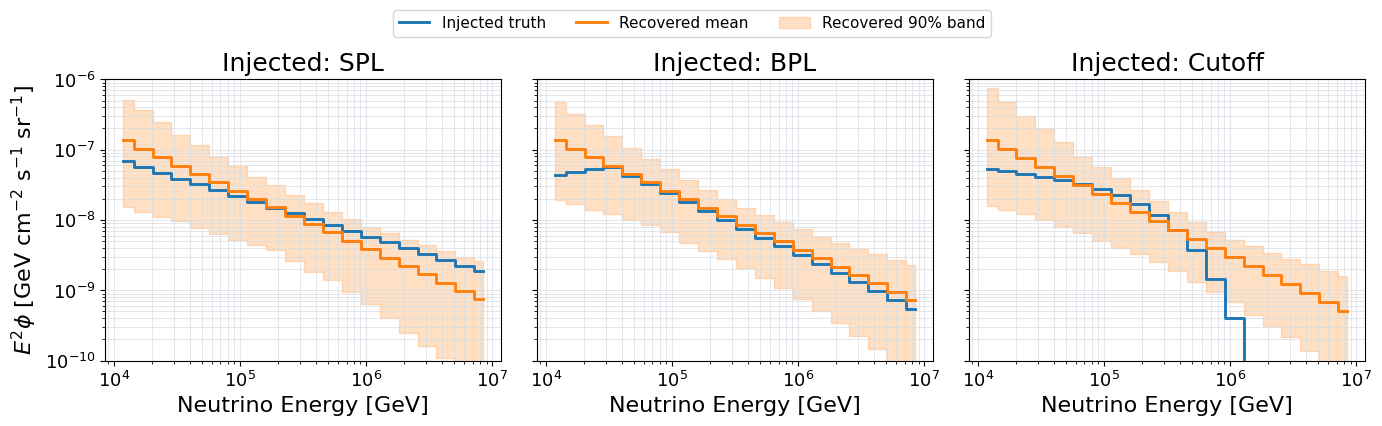

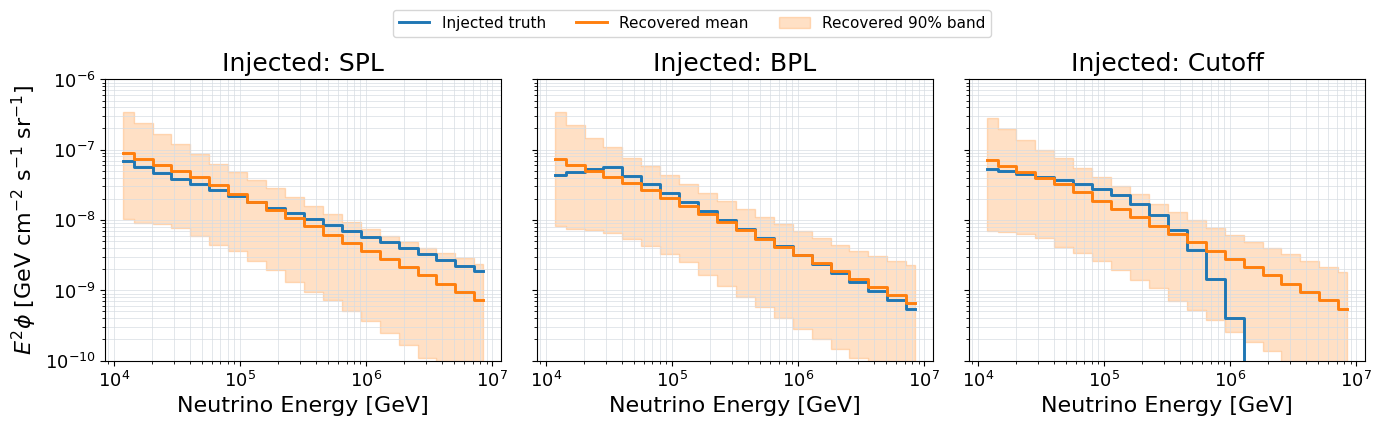

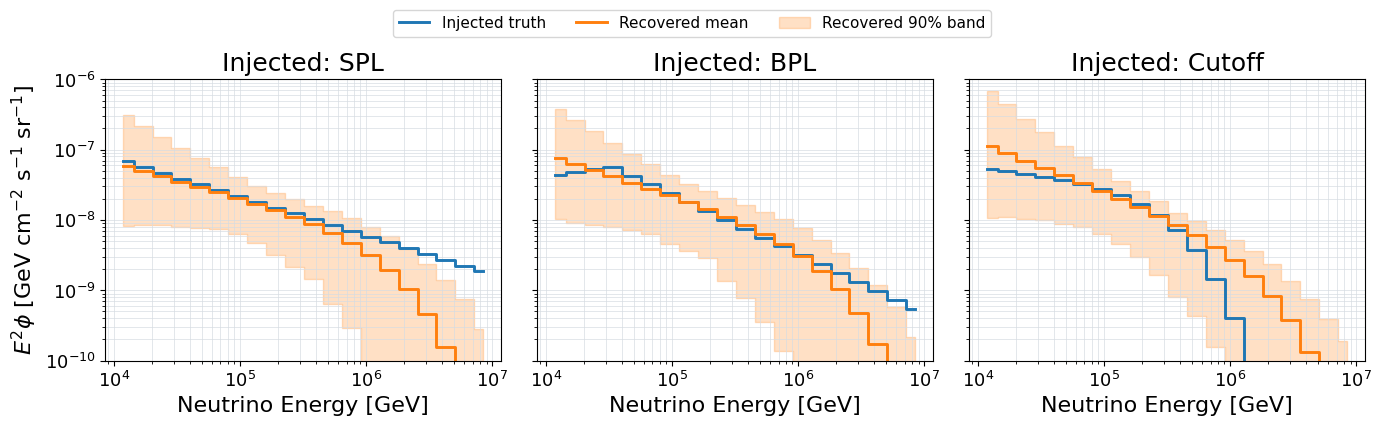

In [52]:
# Optional: one figure per recovered model (columns = injected models)
for rec in recover_models:
    fig, axes = plt.subplots(1, len(inject_models), figsize=(14, 4.0), sharex=True, sharey=True)
    if len(inject_models) == 1:
        axes = [axes]

    for j, inj in enumerate(inject_models):
        ax = axes[j]
        cs = case_store[(inj, rec)]
        ds = cs['ds']

        use_mala = np.isfinite(cs['row']['mala_rhat_max']) and (cs['row']['mala_rhat_max'] < 1.2)
        summary = cs['mala_summary'] if use_mala else cs['rwmh_summary']
        samples = cs['mala'] if use_mala else cs['rwmh']

        tp = ds.true_params
        if inj == 'power_law':
            p_true = {'phi': tp['phi'], 'gamma': tp['gamma']}
        elif inj == 'broken_power_law':
            p_true = {'phi': tp['phi'], 'gamma1': tp['gamma'], 'gamma2': tp['gamma2'], 'E_break': tp['E_break']}
        else:
            p_true = {'phi': tp['phi'], 'gamma': tp['gamma'], 'E_cut': tp['E_cut']}

        p_rec = summary_to_natural_params(summary, rec)

        mu_true = signal_counts_for_model(ds.E_centers, ds.E_widths, inj, p_true)
        mu_rec = signal_counts_for_model(ds.E_centers, ds.E_widths, rec, p_rec)

        e2phi_true = ds.E_centers**2 * np.clip(mu_true / ds.E_widths, 1e-40, None)
        e2phi_rec = ds.E_centers**2 * np.clip(mu_rec / ds.E_widths, 1e-40, None)

        # 90% recovered band
        chain_arr = _stack_chains(samples).reshape(-1, _stack_chains(samples).shape[-1])
        n_draw = min(250, len(chain_arr))
        idx = np.linspace(0, len(chain_arr)-1, n_draw, dtype=int)
        draws = []
        for k in idx:
            vec = chain_arr[k]
            name_map = {name: vec[ii] for ii, name in enumerate(cs['names'])}
            p_draw = {n: (np.exp(v) if n.startswith('log_') else v) for n, v in name_map.items()}
            p_nat = {k2.replace('log_', ''): float(v2) for k2, v2 in p_draw.items()}

            if rec == 'power_law':
                pars = {'phi': p_nat['phi'], 'gamma': p_nat['gamma']}
            elif rec == 'broken_power_law':
                pars = {'phi': p_nat['phi'], 'gamma1': p_nat['gamma1'], 'gamma2': p_nat['gamma2'], 'E_break': p_nat['E_break']}
            else:
                pars = {'phi': p_nat['phi'], 'gamma': p_nat['gamma'], 'E_cut': p_nat['E_cut']}

            mu_d = signal_counts_for_model(ds.E_centers, ds.E_widths, rec, pars)
            draws.append(ds.E_centers**2 * np.clip(mu_d / ds.E_widths, 1e-40, None))

        draws = np.asarray(draws)
        lo = np.quantile(draws, 0.05, axis=0)
        hi = np.quantile(draws, 0.95, axis=0)

        ax.step(ds.E_centers, e2phi_true, where='mid', lw=2.1, color='tab:blue', label='Injected truth' if j==0 else None)
        ax.step(ds.E_centers, e2phi_rec, where='mid', lw=2.1, color='tab:orange', label='Recovered mean' if j==0 else None)
        ax.fill_between(ds.E_centers, lo, hi, step='mid', color='tab:orange', alpha=0.24,
                        label='Recovered 90% band' if j==0 else None)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_ylim(1e-10, 1e-6)
        ax.grid(True, which='both', color='#D7DCE2', alpha=0.7, linewidth=0.7)
        ax.set_title(f"Injected: {MODEL_LABEL[inj]}")
        if j == 0:
            ax.set_ylabel(r"$E^2\phi$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")
        ax.set_xlabel('Neutrino Energy [GeV]')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=True, bbox_to_anchor=(0.5, 1.08))
    # fig.suptitle(f"Recovered: {MODEL_LABEL[rec]}", y=1.08)
    fig.tight_layout()
    plt.show()